In [1]:
from google.colab import drive
drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/ETHUSD_1m_Binance.csv'

Mounted at /content/drive


In [3]:
import pandas as pd
df = pd.read_csv(drive_path, delimiter=',')
display(df.head())

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2017-08-17 04:00:00,301.13,301.13,301.13,301.13,0.42643,2017-08-17 04:00:59.999,128.410866,2.0,0.42643,128.410866,0.0
1,2017-08-17 04:01:00,301.13,301.13,301.13,301.13,2.75787,2017-08-17 04:01:59.999,830.477393,4.0,2.75787,830.477393,0.0
2,2017-08-17 04:02:00,300.00,300.00,300.00,300.00,0.09930,2017-08-17 04:02:59.999,29.790000,2.0,0.09930,29.790000,0.0
3,2017-08-17 04:03:00,300.00,300.00,300.00,300.00,0.31389,2017-08-17 04:03:59.999,94.167000,3.0,0.00000,0.000000,0.0
4,2017-08-17 04:04:00,301.13,301.13,301.13,301.13,0.23202,2017-08-17 04:04:59.999,69.868183,1.0,0.23202,69.868183,0.0


In [8]:
df['Open time'] = pd.to_datetime(df['Open time'], format='%Y-%m-%d %H:%M:%S')
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4278673 entries, 0 to 4278672
Data columns (total 12 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   Open time                     datetime64[ns]
 1   Open                          float64       
 2   High                          float64       
 3   Low                           float64       
 4   Close                         float64       
 5   Volume                        float64       
 6   Close time                    object        
 7   Quote asset volume            float64       
 8   Number of trades              float64       
 9   Taker buy base asset volume   float64       
 10  Taker buy quote asset volume  float64       
 11  Ignore                        float64       
dtypes: datetime64[ns](1), float64(10), object(1)
memory usage: 391.7+ MB


None

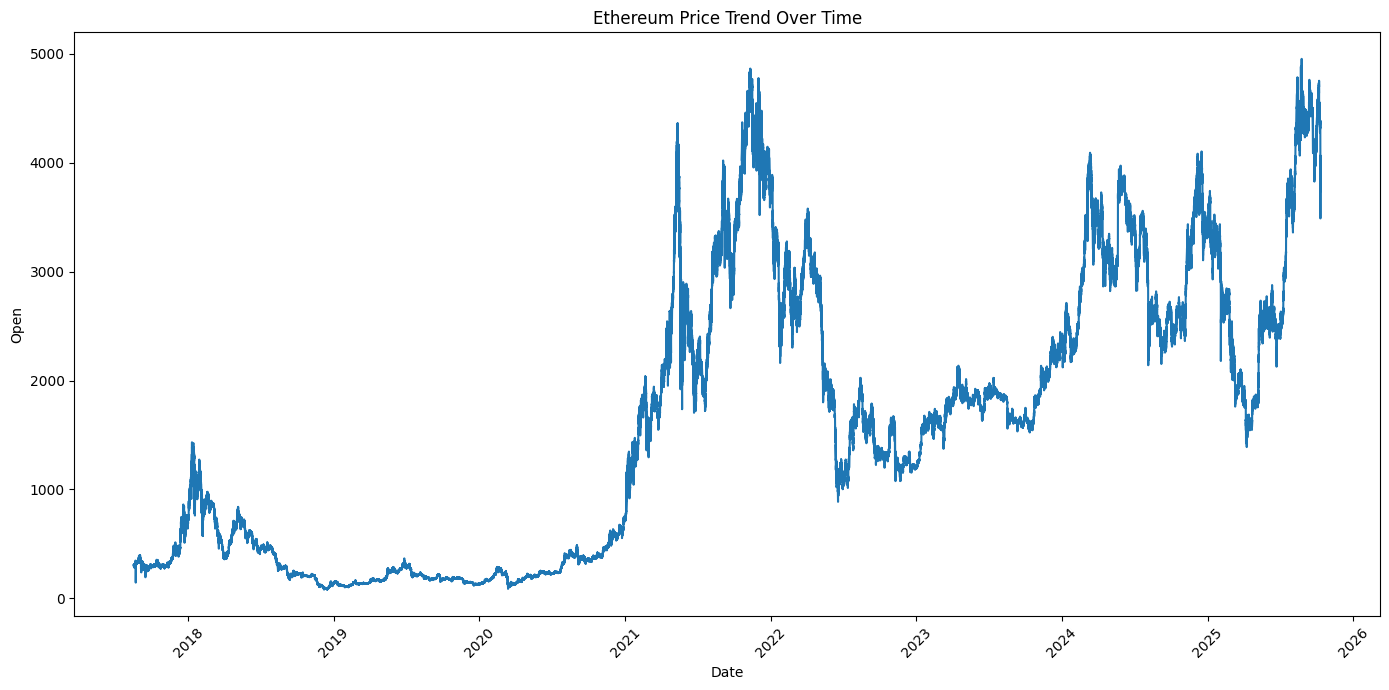

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(x='Open time', y='Open', data=df)
plt.title('Ethereum Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Open')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Filter data

### Subtask:
Filter the DataFrame to create training data (2021-2024) and testing data (2024-2025) based on the 'Date' column.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 10, 64)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,075 (94.04 KB)

 Trainable params: 24,075 (94.04 KB)

 Non-trainable params: 0 (0.00 B)

Training the simpler Conv1D-LSTM model...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


65667/65667 ━━━━━━━━━━━━━━━━━━━━ 318s 5ms/step - loss: 9.2292e-05 - mean_absolute_error: 0.0041 - val_loss: 2.5634e-06 - val_mean_absolute_error: 0.0011
Epoch 2/20
65667/65667 ━━━━━━━━━━━━━━━━━━━━ 321s 5ms/step - loss: 1.1696e-05 - mean_absolute_error: 0.0019 - val_loss: 6.6111e-06 - val_mean_absolute_error: 0.0021
Epoch 3/20
65667/65667 ━━━━━━━━━━━━━━━━━━━━ 323s 5ms/step - loss: 9.6469e-06 - mean_absolute_error: 0.0016 - val_loss: 1.1439e-06 - val_mean_absolute_error: 6.9599e-04
Epoch 4/20
65667/65667 ━━━━━━━━━━━━━━━━━━━━ 330s 5ms/step - loss: 6.6073e-06 - mean_absolute_error: 0.0014 - val_loss: 1.0120e-06 - val_mean_absolute_error: 7.1871e-04
Epoch 5/20
65667/65667 ━━━━━━━━━━━━━━━━━━━━ 326s 5ms/step - loss: 5.9954e-06 - mean_absolute_error: 0.0014 - val_loss: 9.6346e-07 - val_mean_absolute_error: 6.9494e-04
Epoch 6/20
65667/65667 ━━━━━━━━━━━━━━━━━━━━ 326s 5ms/step - loss: 6.0612e-06 - mean_absolute_error: 0.0013 - val_loss: 2.7324e-06 - val_mean_absolute_error: 0.0012
Epoch 7/20
6566

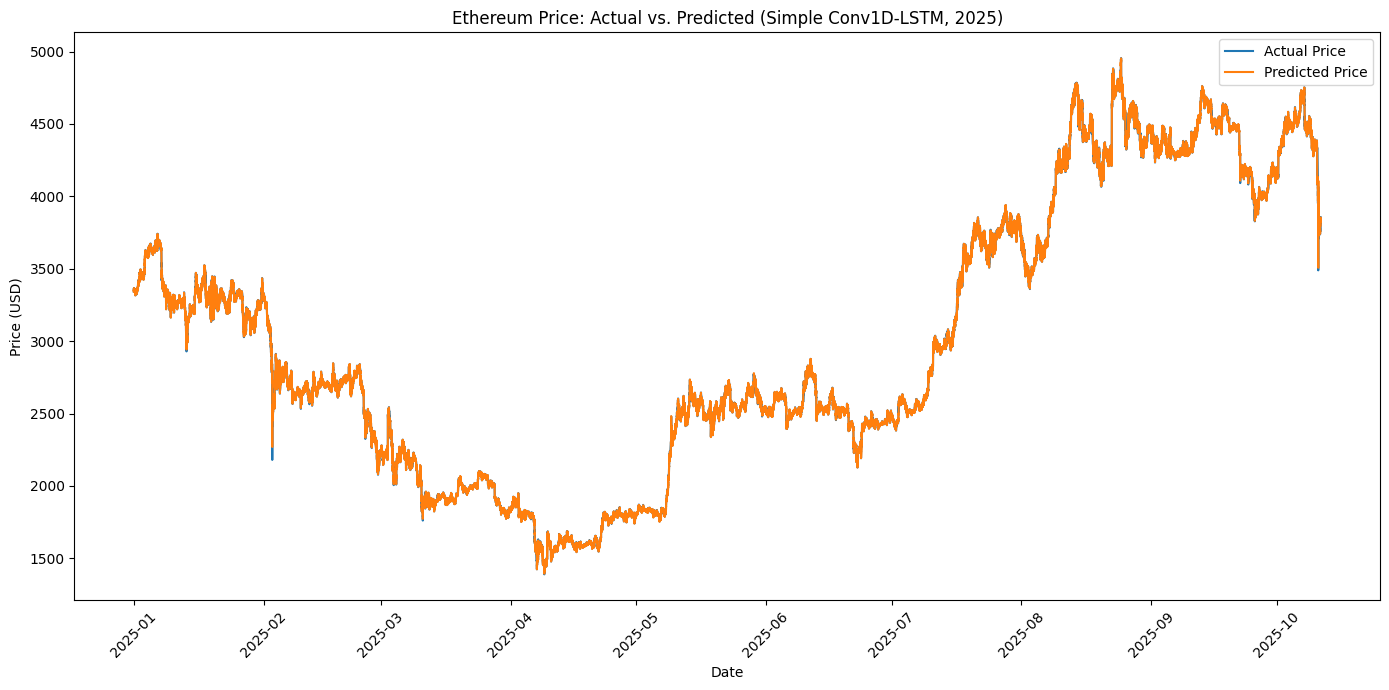

Simple Conv1D-LSTM Model Evaluation:
Mean Squared Error (MSE): 11.11
Root Mean Squared Error (RMSE): 3.33
Mean Absolute Error (MAE): 2.13


In [11]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Conv1D, Flatten
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Filter data for training (2021-2024) and testing (2025)
train_df = df[(df['Open time'] >= '2021-01-01') & (df['Open time'] <= '2024-12-31')].copy()
test_df = df[(df['Open time'] >= '2025-01-01') & (df['Open time'] <= '2025-12-31')].copy()

# Select the features for scaling and sequencing
features = ['Open', 'High', 'Low', 'Close', 'Volume']
train_data = train_df[features].values
test_data = test_df[features].values

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

# Define the sequence length
look_back = 10

# Create sequences using TimeseriesGenerator
train_generator = TimeseriesGenerator(train_data_scaled, train_data_scaled[:, 3], # Predict 'Close'
                                      length=look_back, batch_size=32)

test_generator = TimeseriesGenerator(test_data_scaled, test_data_scaled[:, 3], # Predict 'Close'
                                     length=look_back, batch_size=32)

# Define the simpler model with Conv1D and LSTM
model_simple_conv_lstm = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(look_back, len(features))),
    LSTM(50),
    Dense(1)
])

model_simple_conv_lstm.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

model_simple_conv_lstm.summary()

# Train the model
print("Training the simpler Conv1D-LSTM model...")
history_simple = model_simple_conv_lstm.fit(train_generator, epochs=20, verbose=1, validation_data=test_generator)

# Make predictions
print("Making predictions with the simpler model...")
predictions_scaled_simple = model_simple_conv_lstm.predict(test_generator)


# Inverse scale predictions
dummy_array_simple = np.zeros((len(predictions_scaled_simple), len(features)))
dummy_array_simple[:, 3] = predictions_scaled_simple.flatten()
predictions_simple = scaler.inverse_transform(dummy_array_simple)[:, 3]

actual_prices_for_comparison_simple = test_data[look_back:, 3]

dates_for_comparison_simple = test_df['Open time'].iloc[look_back:].reset_index(drop=True)

comparison_df_simple = pd.DataFrame({
    'Date': dates_for_comparison_simple,
    'Actual Price': actual_prices_for_comparison_simple,
    'Predicted Price': predictions_simple
})

plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Actual Price', data=comparison_df_simple, label='Actual Price')
sns.lineplot(x='Date', y='Predicted Price', data=comparison_df_simple, label='Predicted Price')
plt.title('Ethereum Price: Actual vs. Predicted (Simple Conv1D-LSTM, 2025)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

mse_simple = mean_squared_error(comparison_df_simple['Actual Price'], comparison_df_simple['Predicted Price'])
rmse_simple = np.sqrt(mse_simple)
mae_simple = mean_absolute_error(comparison_df_simple['Actual Price'], comparison_df_simple['Predicted Price'])

print(f'Simple Conv1D-LSTM Model Evaluation:')
print(f'Mean Squared Error (MSE): {mse_simple:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse_simple:.2f}')
print(f'Mean Absolute Error (MAE): {mae_simple:.2f}')

In [ ]:
model_simple_conv_lstm.save('main_minute_conv_cbam.h5')